### Phol Castañeda Henao Y Leonardo Guevara Atehortúa.

### Grupo 62

---

# Taller Análisis Exploratorio de Datos

## Paso 1: Carga de datos

Abra el archivo en Excel o bloc de notas, y revise sí hay algo particular con los datos. Este paso es importante para evitar problemas posteriores al cargar los datos.

Cargar el archivo dado, que contiene un dataset cuya información puede consultar en [IBM](https://community.ibm.com/community/user/businessanalytics/blogs/steven-macko/2019/07/11/telco-customer-churn-1113).

Responda las siguientes preguntas:

- ¿Cuántas filas y columnas tiene el dataframe?
- ¿De qué tipo de dato es cada columna?
- ¿Las variables están en el tipo de dato correcto para su contenido?


1. El dataframe tiene 7043 filas y 33 columnas.

2. float64(3), int64(6), object(24)

3. Todas están en su tipo de dato correcto, excepto total_charges que debería ser tipo numérico pero dice tipo object. Para ellos se usó na_values=[' ?', ' '].

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(
    "./Telco_customer_churn.csv",
    na_values=[' ?', ' ']
)

pd.set_option("display.max_columns", None)
df.head()



#df.info()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

## Paso 2: Exploración inicial de los datos

Responda las siguientes preguntas:

- ¿Hay valores fuera de rango o imposibles, según el dominio del problema?
- ¿Hay variables que no varían?
- Qué variables *cualitativas* tienen muchos valores únicos (alta cardinalidad)?
- ¿Hay claves primarias o identificadores únicos?

1. No, valores como charges son todos positivos y no se encuentran valores negativos o imposibles.

2. Sí, la variable count tiene un valor constante de 1. También variables como Country y state solo tienen un valor de United States y California respectivamente.

3. City y Lat Long son variables con alta cardinalidad pues tienen 1129 y 1652 valores únicos respectivamente. 

4. Sí la variable CustomerID tiene identificadores únicos, pues se visualiza que el top tiene una frecuencia de 1, indicando que son valores únicos.

In [5]:
df.describe()


,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7032.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,2283.300441,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,2266.771362,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,18.800000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,401.450000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,1397.475000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,3794.737500,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,8684.800000,1.000000,100.000000,6500.000000


In [6]:
df.describe(include='object')

,CustomerID,Country,State,City,Lat Long,Gender,Senior Citizen,Partner,Dependents,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Churn Label,Churn Reason
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,1869
unique,7043,1,1,1129,1652,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2,20
top,3186-AJIEK,United States,California,Los Angeles,"34.02381, -118.156582",Male,No,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No,Attitude of support person
freq,1,7043,7043,305,5,3555,5901,3641,5416,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174,192


In [7]:
for col in df.select_dtypes(include=["object"]).columns:
    print(f'La columna "{col}" tiene las siguientes categorías: \n {df[col].unique()} \n')

La columna "CustomerID" tiene las siguientes categorías: 
 ['3668-QPYBK' '9237-HQITU' '9305-CDSKC' ... '2234-XADUH' '4801-JZAZL'
 '3186-AJIEK'] 

La columna "Country" tiene las siguientes categorías: 
 ['United States'] 

La columna "State" tiene las siguientes categorías: 
 ['California'] 

La columna "City" tiene las siguientes categorías: 
 ['Los Angeles' 'Beverly Hills' 'Huntington Park' ... 'Standish' 'Tulelake'
 'Olympic Valley'] 

La columna "Lat Long" tiene las siguientes categorías: 
 ['33.964131, -118.272783' '34.059281, -118.30742' '34.048013, -118.293953'
 ... '40.346634, -120.386422' '41.813521, -121.492666'
 '39.191797, -120.212401'] 

La columna "Gender" tiene las siguientes categorías: 
 ['Male' 'Female'] 

La columna "Senior Citizen" tiene las siguientes categorías: 
 ['No' 'Yes'] 

La columna "Partner" tiene las siguientes categorías: 
 ['No' 'Yes'] 

La columna "Dependents" tiene las siguientes categorías: 
 ['No' 'Yes'] 

La columna "Phone Service" tiene las siguien

## Paso 3: Identificación de datos duplicados, datos nulos y problemas de formateo

Descarte las variables que solo toman un valor y las que son clave primaria. También descarte las variables **City** y **Lat Long**.

Responda las siguientes preguntas:

- ¿Qué variables tienen valores nulos? ¿En qué proporción?
- ¿Hay registros duplicados?
- ¿Hay variables con problemas de formateo (fechas, monedas, mayúsculas/minúsculas)?

1. Total Charges tiene valores nulos. El 0.15% de los registros en esta variable son nulos. Y para la variable Churn Reason el 73.46% son nulos.

2. No hay registros duplicados

3. No hay problemas de formateo. Todas las variables categóricas empiezan por mayúsculas. 

In [8]:
#Descartando variables
df = df.drop(columns=['CustomerID','Count','Country','State','City','Lat Long'])





In [9]:
df.isnull().sum().sort_values(ascending=False)*100/df.shape[0]

Churn Reason         73.463013
Total Charges         0.156183
Zip Code              0.000000
Gender                0.000000
Senior Citizen        0.000000
Partner               0.000000
Dependents            0.000000
Tenure Months         0.000000
Phone Service         0.000000
Latitude              0.000000
Longitude             0.000000
Internet Service      0.000000
Multiple Lines        0.000000
Online Security       0.000000
Online Backup         0.000000
Streaming TV          0.000000
Streaming Movies      0.000000
Device Protection     0.000000
Tech Support          0.000000
Paperless Billing     0.000000
Contract              0.000000
Monthly Charges       0.000000
Payment Method        0.000000
Churn Label           0.000000
Churn Value           0.000000
Churn Score           0.000000
CLTV                  0.000000
dtype: float64

In [10]:
print('Número de registros duplicados: ', df.duplicated().sum())

Número de registros duplicados:  0


In [11]:
for col in df.select_dtypes(include=["object"]).columns:
    print(f'La columna "{col}" tiene las siguientes categorías: \n {df[col].unique()} \n')

La columna "Gender" tiene las siguientes categorías: 
 ['Male' 'Female'] 

La columna "Senior Citizen" tiene las siguientes categorías: 
 ['No' 'Yes'] 

La columna "Partner" tiene las siguientes categorías: 
 ['No' 'Yes'] 

La columna "Dependents" tiene las siguientes categorías: 
 ['No' 'Yes'] 

La columna "Phone Service" tiene las siguientes categorías: 
 ['Yes' 'No'] 

La columna "Multiple Lines" tiene las siguientes categorías: 
 ['No' 'Yes' 'No phone service'] 

La columna "Internet Service" tiene las siguientes categorías: 
 ['DSL' 'Fiber optic' 'No'] 

La columna "Online Security" tiene las siguientes categorías: 
 ['Yes' 'No' 'No internet service'] 

La columna "Online Backup" tiene las siguientes categorías: 
 ['Yes' 'No' 'No internet service'] 

La columna "Device Protection" tiene las siguientes categorías: 
 ['No' 'Yes' 'No internet service'] 

La columna "Tech Support" tiene las siguientes categorías: 
 ['No' 'Yes' 'No internet service'] 

La columna "Streaming TV" tiene l

## Paso 4: Análisis de variables cuantitativas

Haga análisis de normalidad de las variables cuantitativas. Indique cuáles variables cumplen con el supuesto de normalidad y cuáles no.

Haga un análisis gráfico de outliers, y como resultado de este indique que variables tienen datos atípicos.

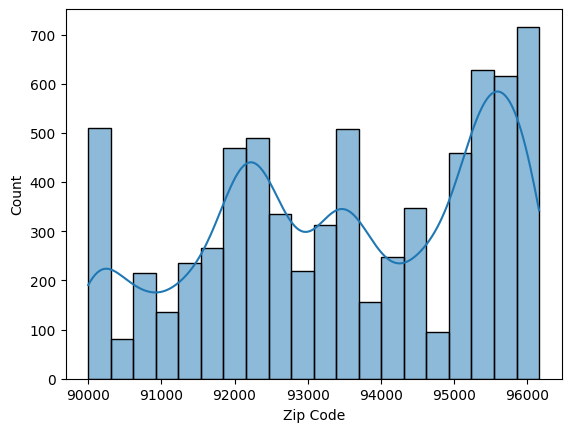

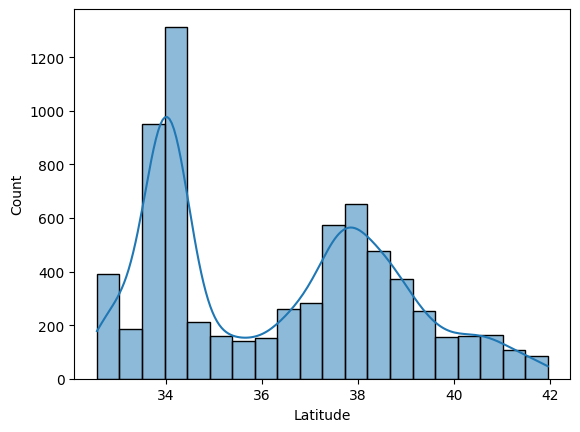

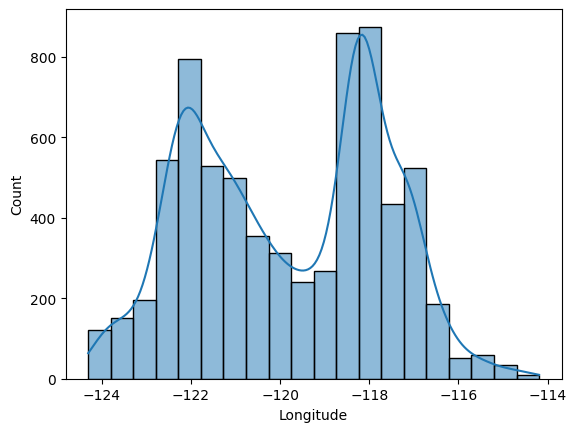

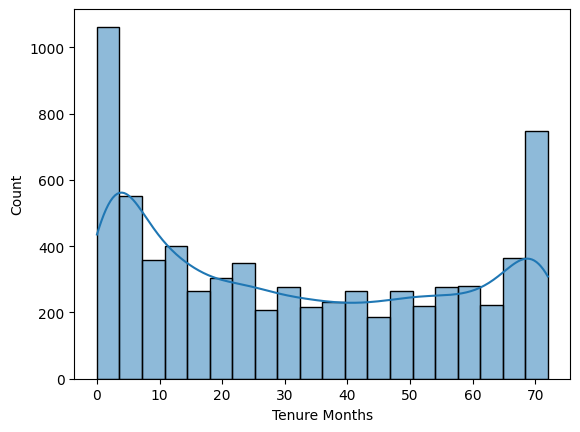

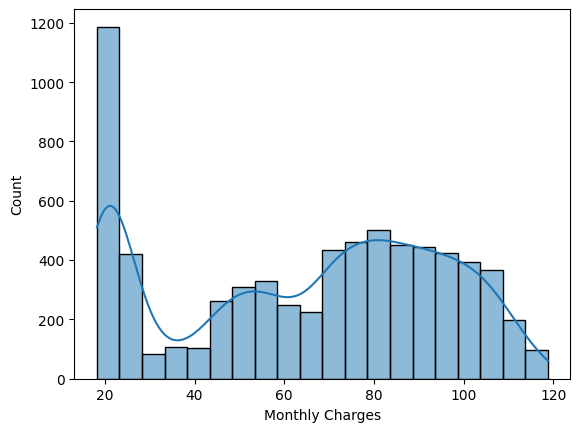

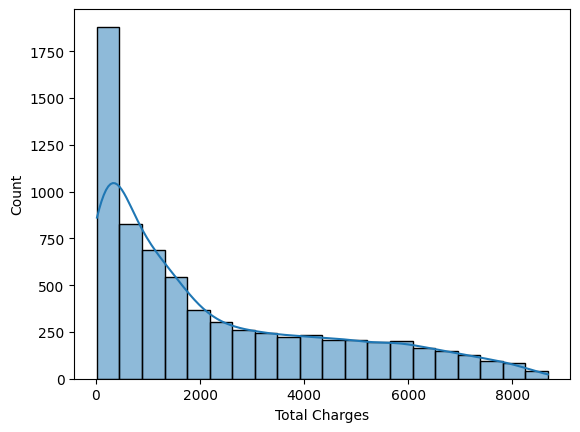

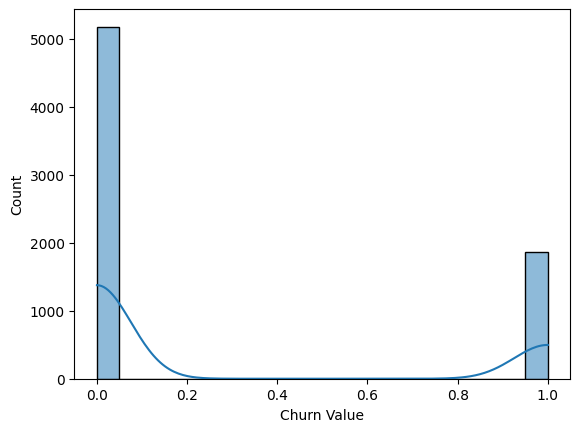

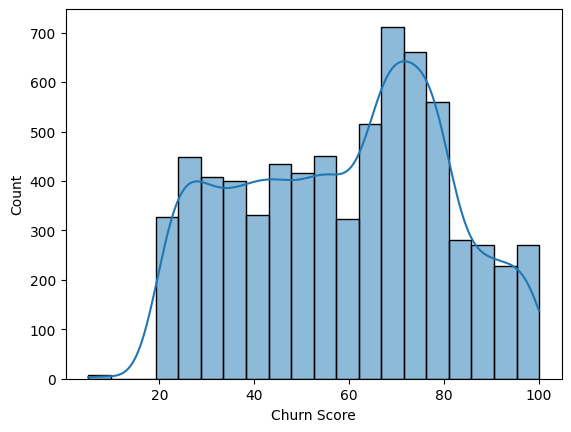

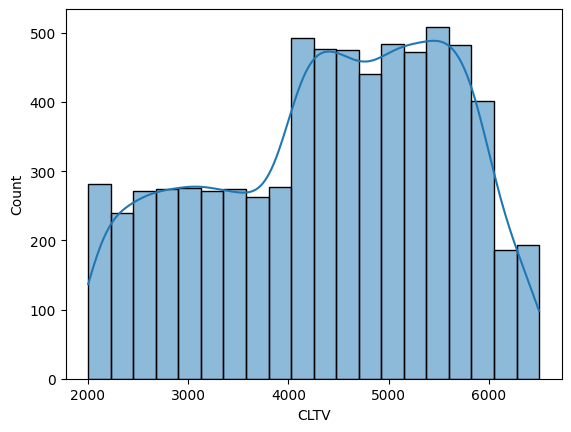

In [12]:
for col in df.select_dtypes(include=['number']).columns:
    plt.figure()
    sns.histplot(data=df, x=col, bins=20, kde=True)
    plt.show();

In [13]:
for num in df.select_dtypes(include=['number']).columns:
    print(f"Asimetría de {num}: {df[num].skew():.3f} \n")

Asimetría de Zip Code: -0.251 

Asimetría de Latitude: 0.304 

Asimetría de Longitude: -0.041 

Asimetría de Tenure Months: 0.240 

Asimetría de Monthly Charges: -0.221 

Asimetría de Total Charges: 0.962 

Asimetría de Churn Value: 1.063 

Asimetría de Churn Score: -0.090 

Asimetría de CLTV: -0.312 



In [14]:
for num in df.select_dtypes(include=['number']).columns:
    print(f"Kurtosis de {num}: {df[num].kurt():.3f} \n")

Kurtosis de Zip Code: -1.154 

Kurtosis de Latitude: -1.136 

Kurtosis de Longitude: -1.136 

Kurtosis de Tenure Months: -1.387 

Kurtosis de Monthly Charges: -1.257 

Kurtosis de Total Charges: -0.232 

Kurtosis de Churn Value: -0.870 

Kurtosis de Churn Score: -1.006 

Kurtosis de CLTV: -0.934 



1. No se encuentra que ninguna variable cumpla estrictamente con el supuesto de normalidad, pues se encuentran diferentes tipo de asimetría, positiva y negativa. 
Aunque algunas presentan valores de asimetría cercanos a cero, sus distribuciones no son unimodales ni presentan forma de campana.

2. No se encuentran outliers en la siguiente gráfica de boxplot, pues no hay puntos por fuera de los bigotes:

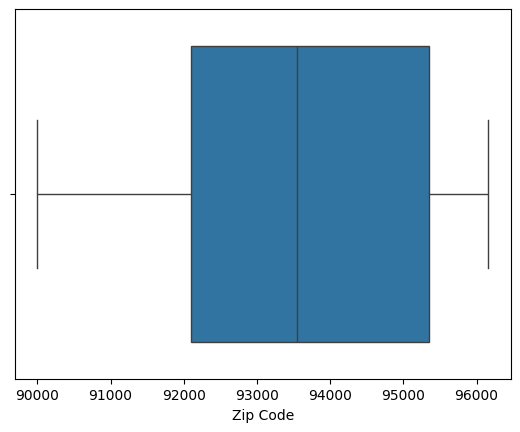

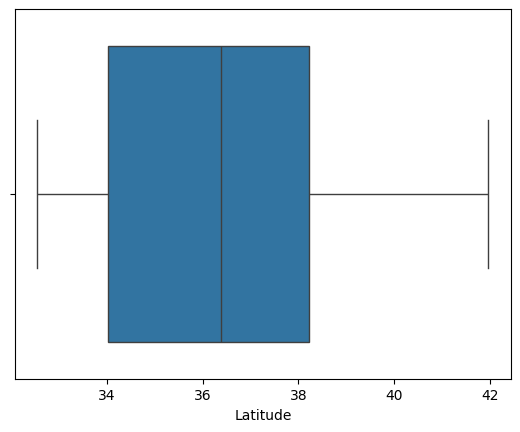

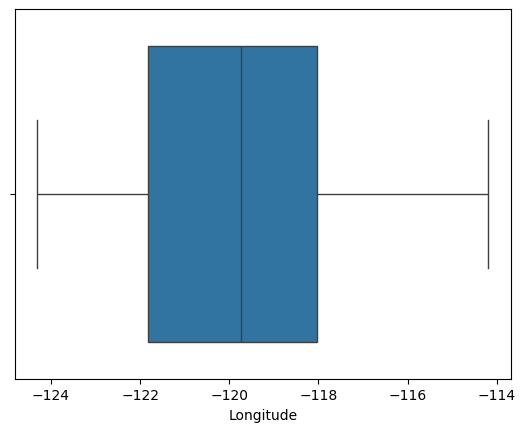

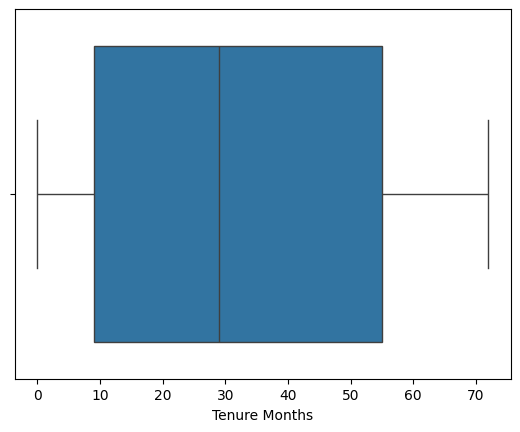

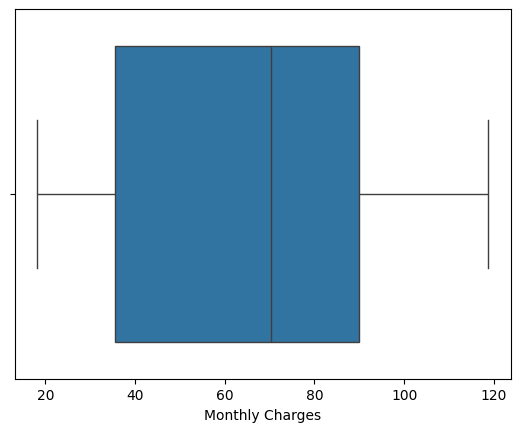

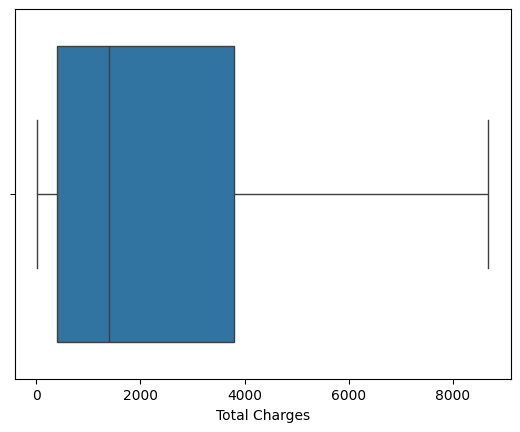

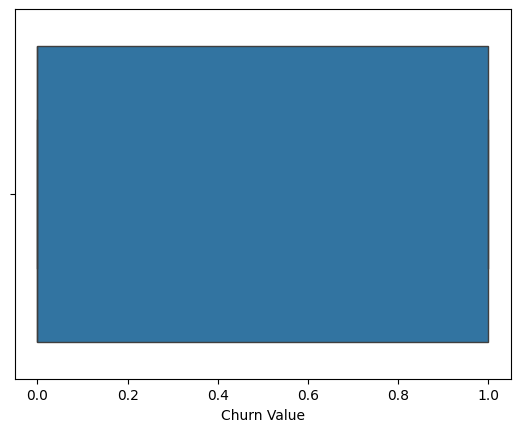

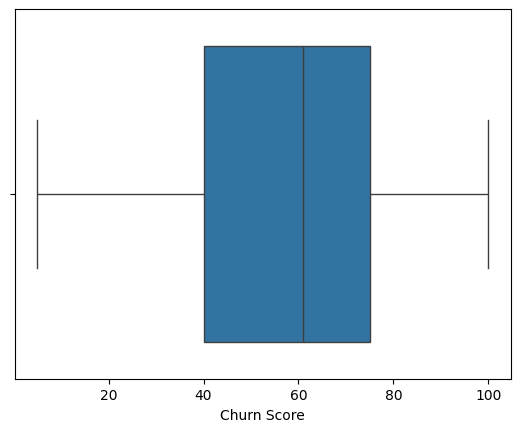

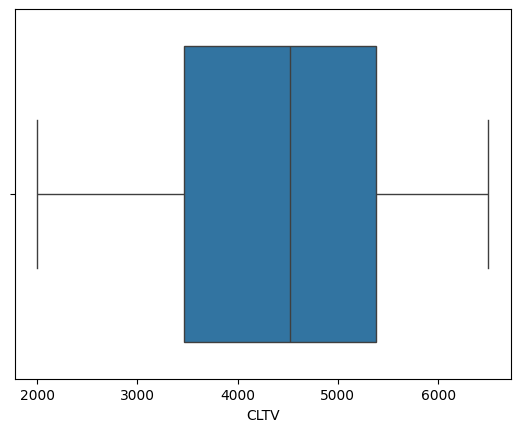

In [15]:
for num in df.select_dtypes(include=['number']).columns:
    plt.figure()
    sns.boxplot(data=df, x=num)
    plt.show();

## Paso 5: Análisis de variables cualitativas

Responda a las siguientes preguntas:

- ¿Cómo se comportan las variables categóricas?
- ¿Existen variables de alta cardinalidad?
- ¿Existen categorías atípicas?

Respuesta:

Las variables categóricas presentan en su mayoría baja cardinalidad, predominando variables que solo tienen dos valores, con distribuciones relativamente balanceadas, como Gender y Partner. Algunas variables muestran desbalance moderado, como Senior Citizen y Phone Service, donde una categoría concentra la mayor parte de los registros.

Se identifica una variable de mayor cardinalidad, Churn Reason, con aproximadamente 20 categorías diferentes. Dentro de esta variable se observan categorías con frecuencias muy bajas, como “Deceased” y “Poor expertise of online support”, las cuales pueden considerarse atípicas porque aparición en el dataset es muy escasa.

In [16]:
cat_vars = df.select_dtypes(include=['object']).columns

for var in cat_vars:
    print(f'El conteo de la variable {var} es: \n {df[var].value_counts()} \n')

El conteo de la variable Gender es: 
 Gender
Male      3555
Female    3488
Name: count, dtype: int64 

El conteo de la variable Senior Citizen es: 
 Senior Citizen
No     5901
Yes    1142
Name: count, dtype: int64 

El conteo de la variable Partner es: 
 Partner
No     3641
Yes    3402
Name: count, dtype: int64 

El conteo de la variable Dependents es: 
 Dependents
No     5416
Yes    1627
Name: count, dtype: int64 

El conteo de la variable Phone Service es: 
 Phone Service
Yes    6361
No      682
Name: count, dtype: int64 

El conteo de la variable Multiple Lines es: 
 Multiple Lines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64 

El conteo de la variable Internet Service es: 
 Internet Service
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64 

El conteo de la variable Online Security es: 
 Online Security
No                     3498
Yes                    2019
No internet service    1526
Name:

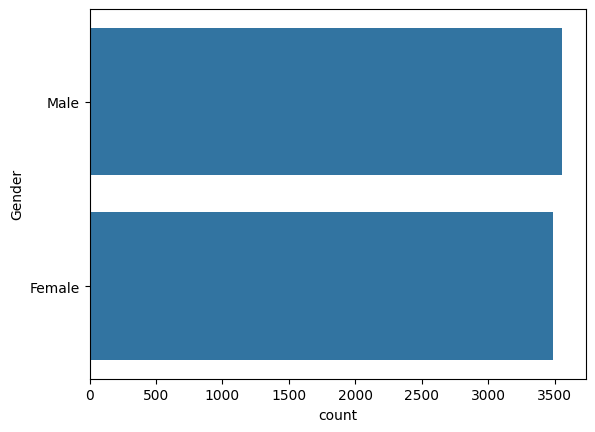

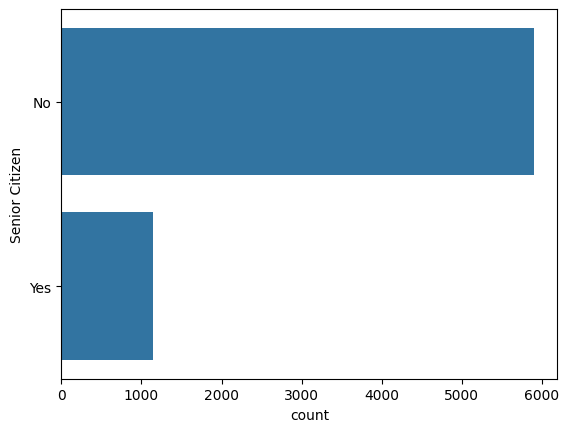

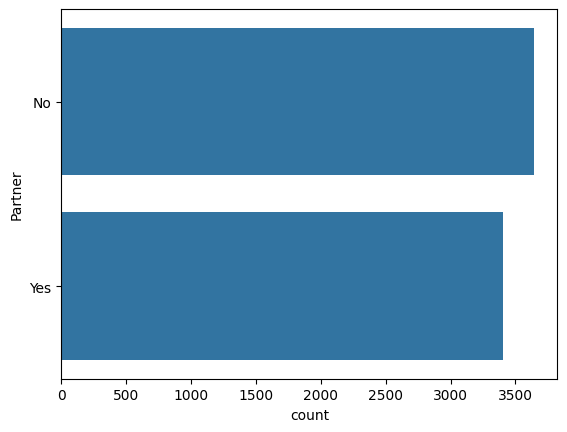

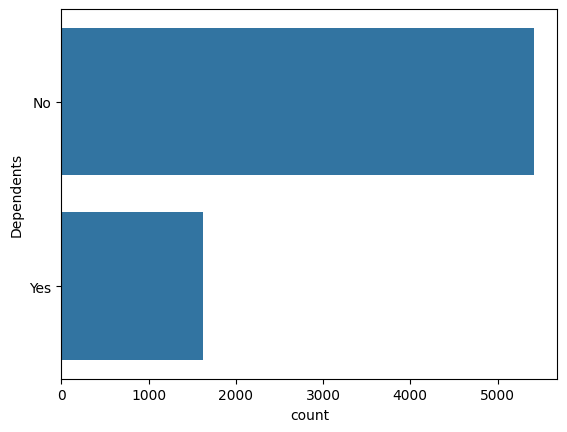

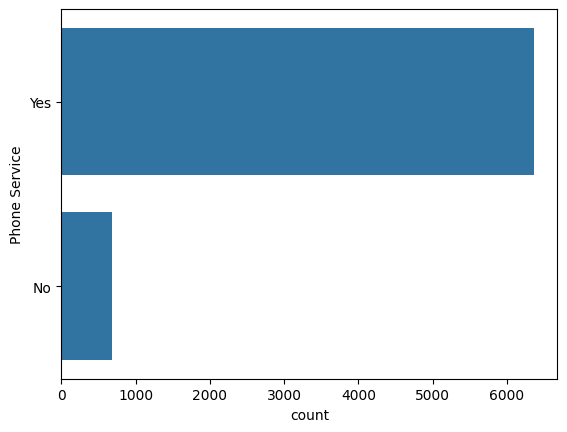

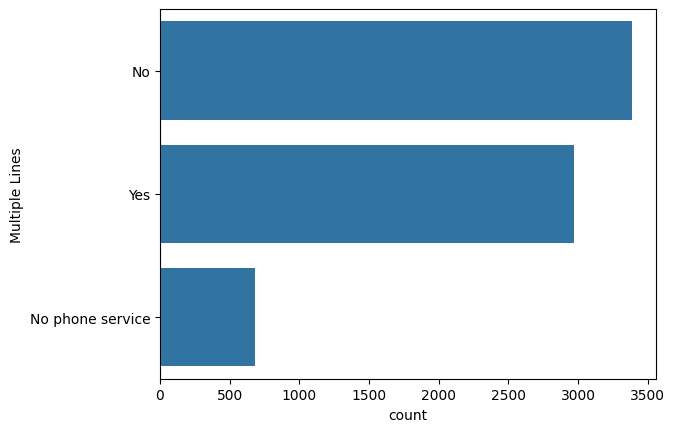

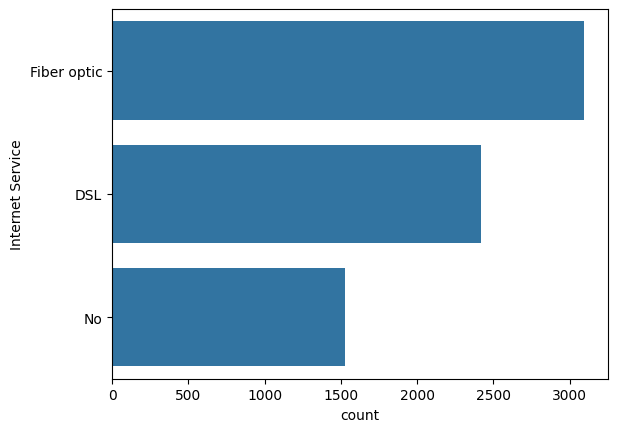

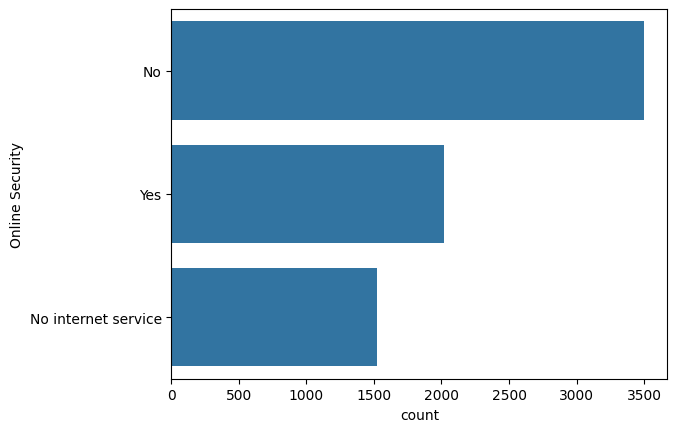

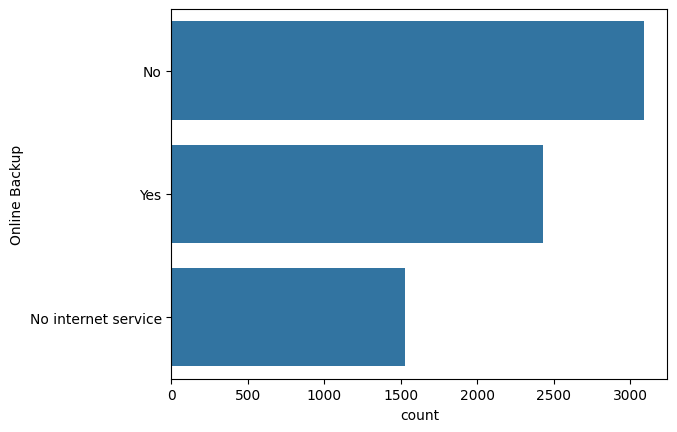

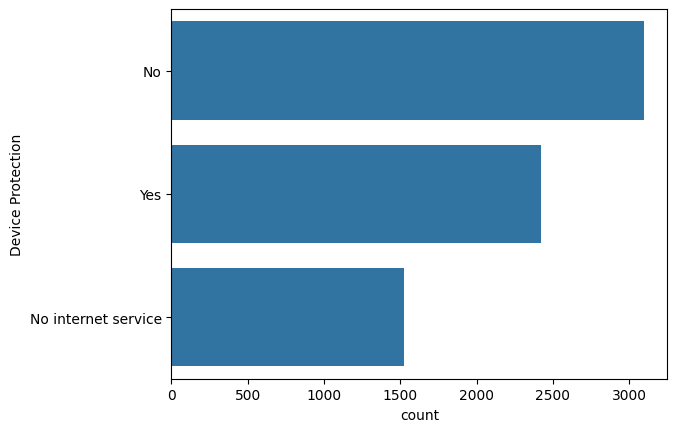

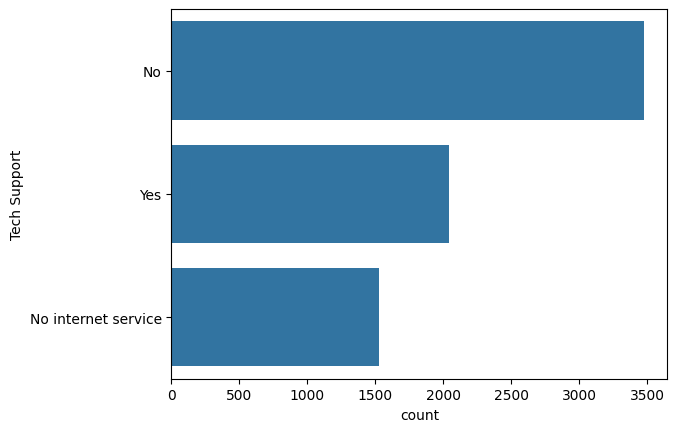

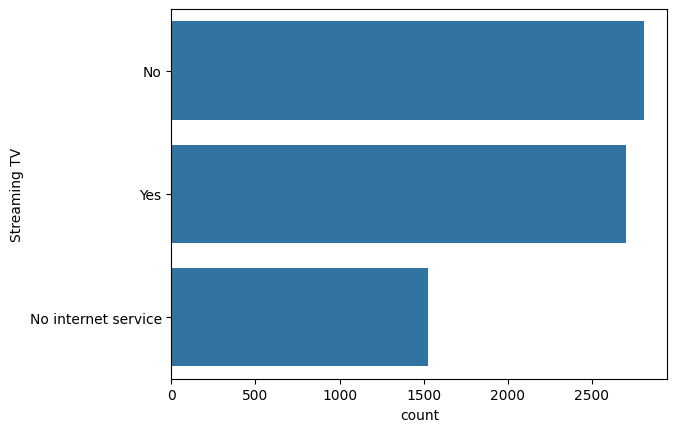

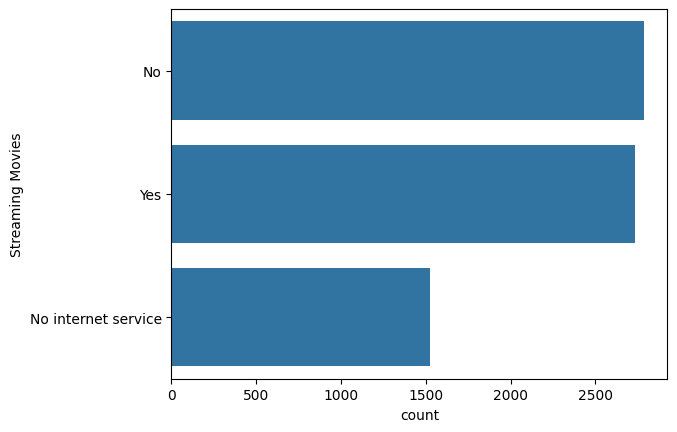

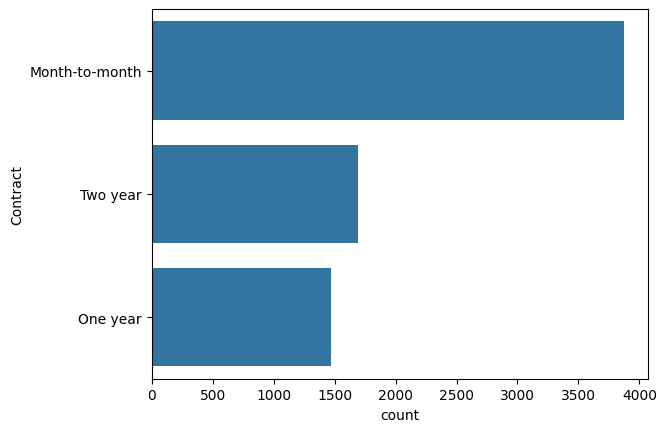

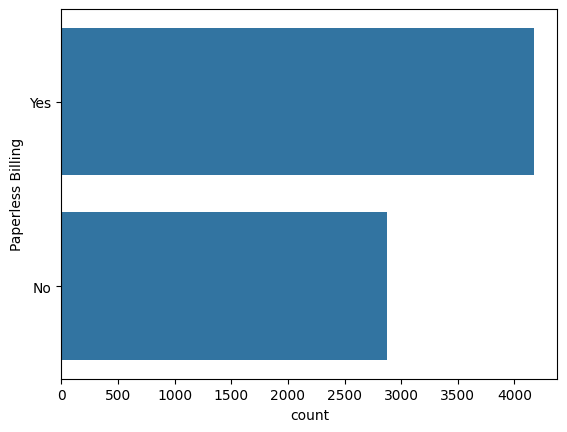

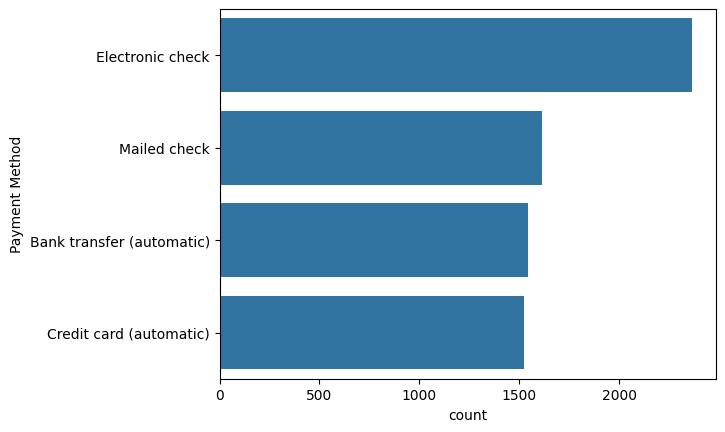

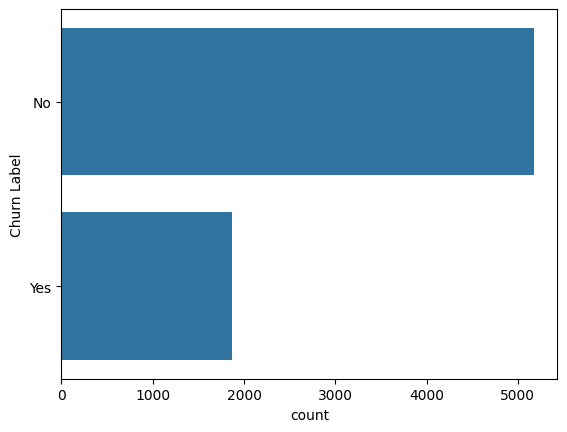

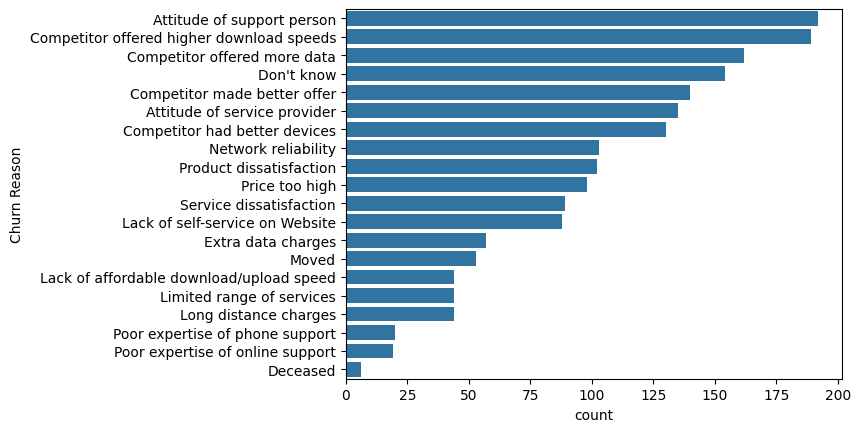

In [17]:
for cat in df.select_dtypes(include=['object']).columns:
    plt.figure()
    sns.countplot(data=df, y=cat, order=df[cat].value_counts().index)
    plt.show();

## Paso 6: Análisis bivariado.

Se va a suponer que con este archivo de datos se desea hacer un modelo de aprendizaje de máquina que prediga la **Churn Value**.


Mediante análisis de gráficas responda las siguientes preguntas:

- ¿Cómo se relaciona cada una de las variables cuantitativas con la variable que se desea predecir?
- ¿Cómo se relaciona cada una de las variables cualitativas con la variable que se desea predecir?
- De acuerdo con estos análisis, ¿cuáles variables parecerían ser buenas predictoras, y cuáles no?


Respuesta:
La variable churn value al ser binaria, se trata como una variable categórica. Para analizar con las cuantitativas usamos boxplot y con las categóricas usamos crosstab.



1. ¿Cómo se relaciona cada una de las variables cuantitativas con la variable que se desea predecir?
Según los boxplot:
- Churn Score (Relación Directa): Los clientes que abandonan presentan puntuaciones significativamente más altas; la mayoría se sitúa por encima de 65, siendo, aparentemente,  un predictor claro.

- Tenure Months (Relación Inversa): A menor tiempo de permanencia, mayor probabilidad de abandono. El grupo de Churn=1 se concentra mayoritariamente por debajo de los 30 meses.

- Monthly Charges (Relación Directa): Existe una tendencia donde cargos mensuales elevados coinciden con una mayor tasa de abandono (la mediana es visiblemente superior en el grupo Churn=1).

- Total Charges: Muestra valores más bajos para quienes abandonan (debido a su corta permanencia), aunque existen casos atípicos de abandono con pagos acumulados altos.

-   CLTV: Se observa una ligera disminución en los clientes que se van, pero el solapamiento entre cajas indica que no es un factor determinante por sí solo.

- Zip Code, Latitude y Longitude: No existe ninguna diferencia visual en la distribución de estas variables entre quienes se quedan y quienes se van. Esto de alguna forma nos dice que la ubicación geográfica no influ Según los heatmaps: ye en la predicción del abandono.

2. ¿Cómo se relaciona cada una de las variables cualitativas con la variable que se desea predecir? Según los heatmaps:
- Churn Label: relación perfecta con Churn Value (son equivalentes: No - 0, Yes - 1).

- Contract: Month-to-month concentra la gran mayoría de los churners (≈0.89 en Churn Value=1); One/Two year se asocian con menor churn (≈0.09 y ≈0.03 en Churn Value=1).

- Payment Method: Electronic check aparece mucho más en Churn Value=1 (≈0.57) que en Churn Value=0 (≈0.25); tarjeta/transferencia automáticas se asocian a menor churn.

- Paperless Billing: Yes se asocia con mayor churn (≈0.75 en Churn Value=1 vs ≈0.54 en Churn Value=0).

- Dependents: No se asocia fuertemente con churn (≈0.94 en Churn Value=1); Yes es mucho más común en no-churn.

- Partner: No se asocia con mayor churn (≈0.64 en Churn Value=1).

- Senior Citizen: Yes es más frecuente en Churn Value=1 (≈0.25 vs ≈0.13), relación moderada.

- Gender: prácticamente sin relación (distribuciones ~50/50 en ambos valores de churn).

- Phone Service y Multiple Lines: relación débil o casi nula (proporciones muy similares entre churn/no-churn).

- Internet Service: Fiber optic se asocia con mayor churn (≈0.69 en Churn Value=1); No internet service es raro en churn (≈0.06).

- Online Security / Tech Support / Online Backup / Device Protection: cuando está en “No” (teniendo internet) se observa más churn; “Yes” se asocia con menor churn. En particular Online Security y Tech Support muestran diferencias grandes (≈0.78 y ≈0.77 en “No” dentro de Churn Value=1).

- Streaming TV / Streaming Movies: relación débil; lo más marcado es que “No internet service” casi no aparece en churn (≈0.06).

- Churn Reason: solo es interpretable para Churn Value=1 (en no-churn los valroes son nulos). Entre quienes se van, destacan motivos como actitud del soporte/proveedor y competencia (mejores dispositivos/velocidad/ofertas), aunque las proporciones por motivo son relativamente pequeñas y repartidas

3. De acuerdo con estos análisis, ¿cuáles variables parecerían ser buenas predictoras, y cuáles no? De acuerdo con los boxplots y heatmaps, las variables que serían buenas predictoras para Churn Value, serian las siguientes:

- Tenure Months: fuerte relación inversa (menos antigüedad, más churn).

- Monthly Charges: relación directa moderada, es decir que al haber cargos mensuales más altos, Churn Value tiende a tener un valor de 1.

- Total Charges: suele ser menor cuando el Churn Value tiene un valor de 1.

- Contract: Un predictor muy fuerte, ya que en su valor "Month-to-month" se asocida mucho al Churn Value : 1, mientras que 1–2 años se asocia a un Churn Value : 0.

- Payment Method: Es un predictor muy fuerte, ya que cuando su valor es  "Electronic check" se asociado mas a Churn Value igual a 1, mientras que sus otros valores se asocian a un Churn Value de 0.

- Paperless Billing: Moderada, su valor Yes está un poco asociado al Churn Value 1.

- Internet Service: Fiber optic se asocia a un Churn Value de 1, mientras que “No internet” se asocia a un Churn Value de 0.

- Online Security: Su valor "No" se asocia a un Churn Value "1".

- Tech Support: Al igual que con Online Security, Su valor "No" se asocia a un Churn Value "1". 

Cabe mencionar, que a pesar de la fuerte correlación que tiene Churn Value con Churn Label, Churn Score y Churn Reason, no deberían usarse para predecir el valor Churn Value, debido a que son variables que contienen un valor que se genera después de tener el Churn Value (se genera después de que el cliente ya se fue). En otras palabras, podria decirse que usar esas variables es como "hacer trampa", y un modelo que las tuviera en cuenta no serviría para predecir el valor Churn Value en un caso real.

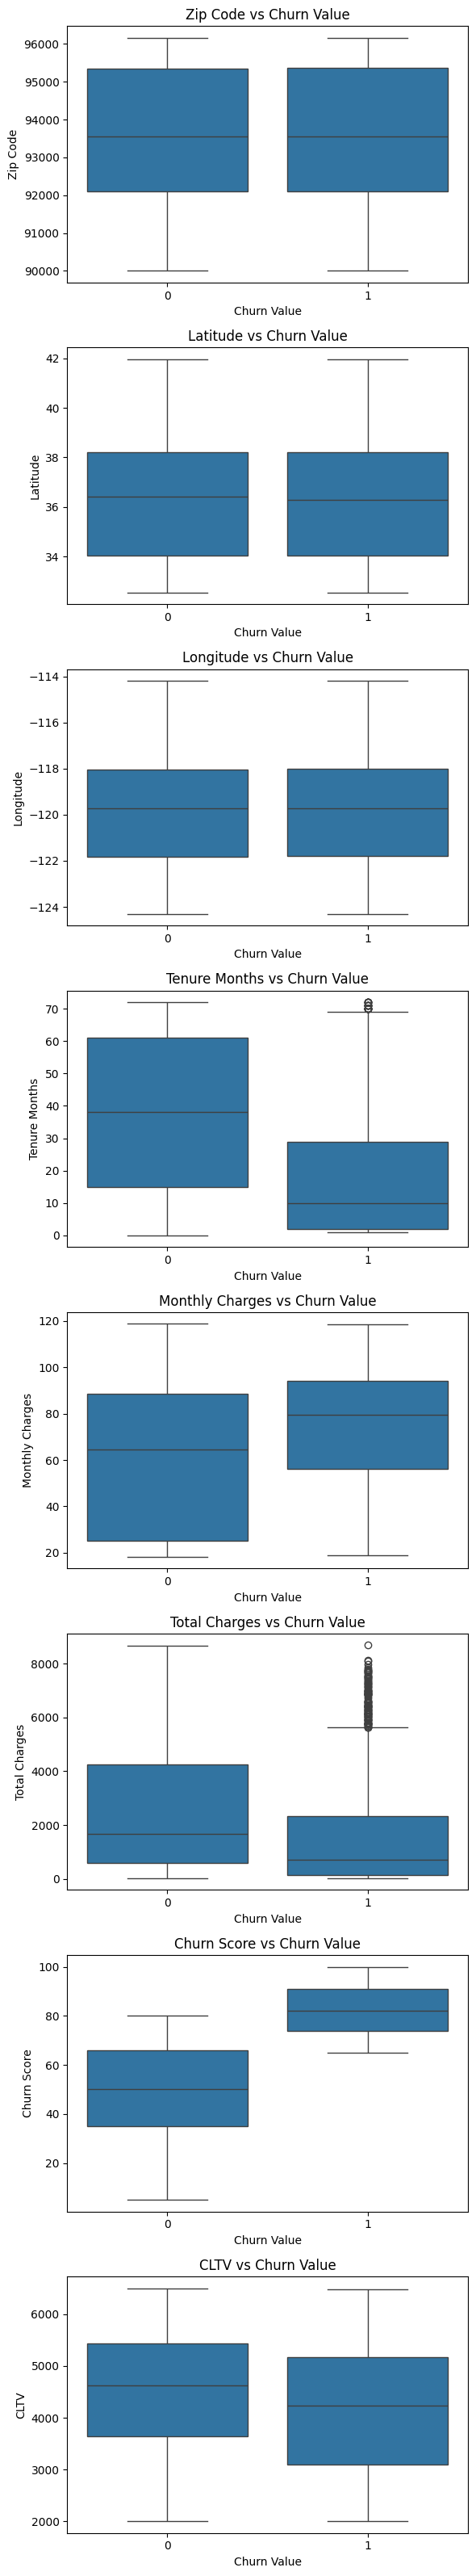

In [19]:
# Variable cualitativa
categorical_var = "Churn Value"

# Variables cuantitativas (excluyendo la binaria)
numeric_cols = df.select_dtypes(include=['number']).columns
numeric_cols = [col for col in numeric_cols if col != categorical_var]

plt.figure(figsize=(6, 4*len(numeric_cols)))  # una sola figura grande

for i, col in enumerate(numeric_cols):
    plt.subplot(len(numeric_cols), 1, i+1)  # varios gráficos en la misma imagen
    sns.boxplot(data=df, x=categorical_var, y=col)
    plt.title(f"{col} vs {categorical_var}")

plt.tight_layout()
plt.show()

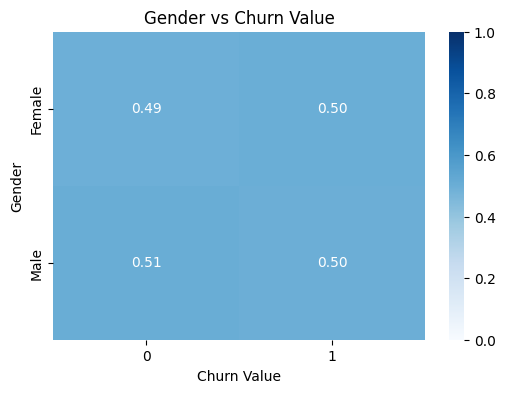

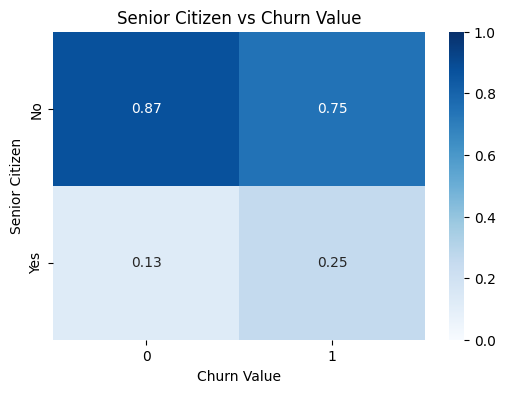

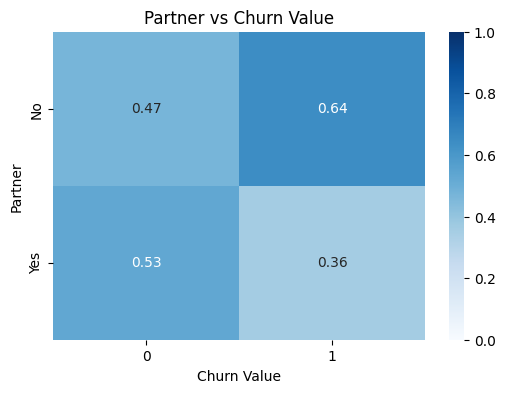

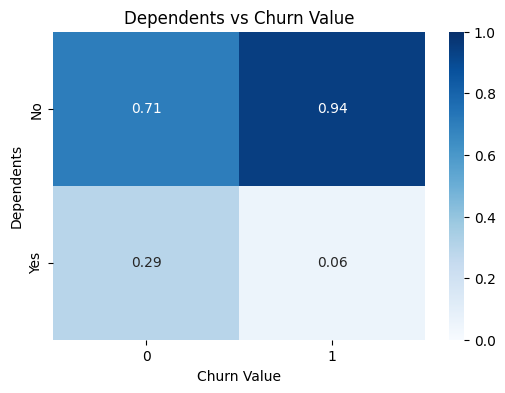

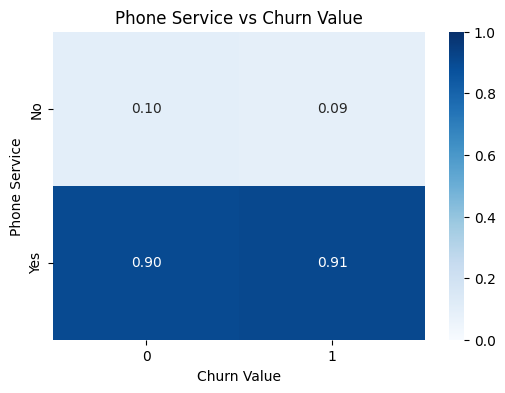

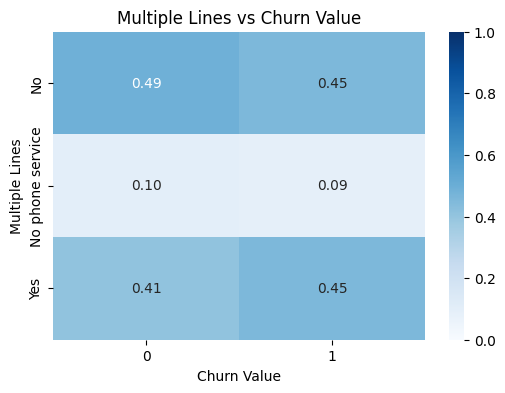

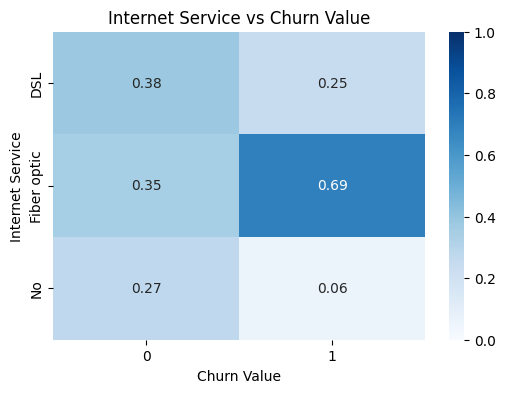

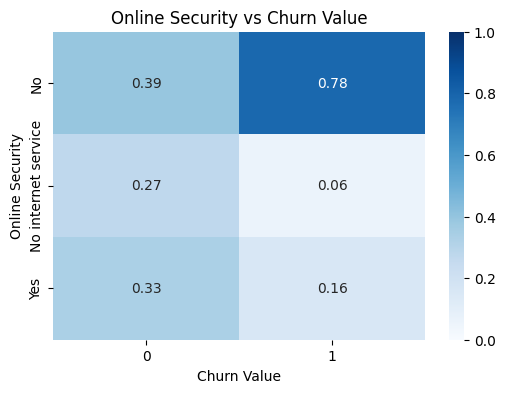

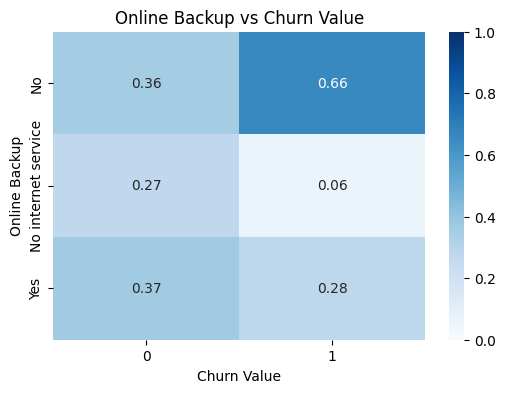

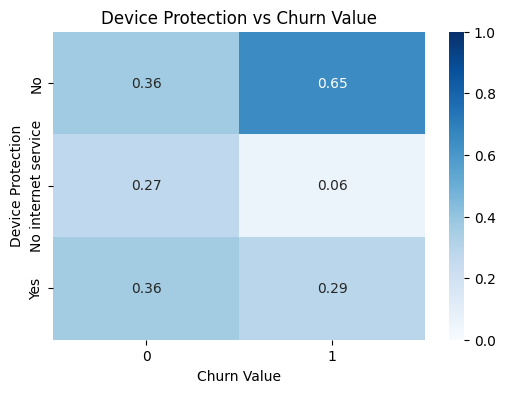

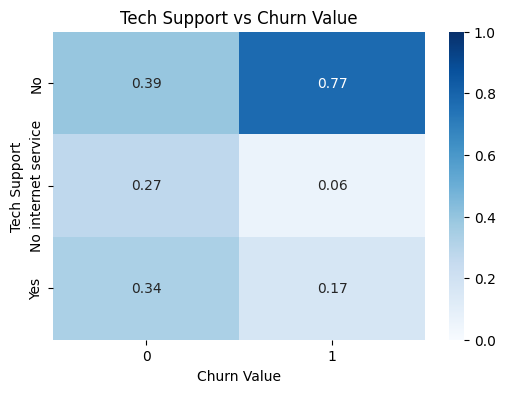

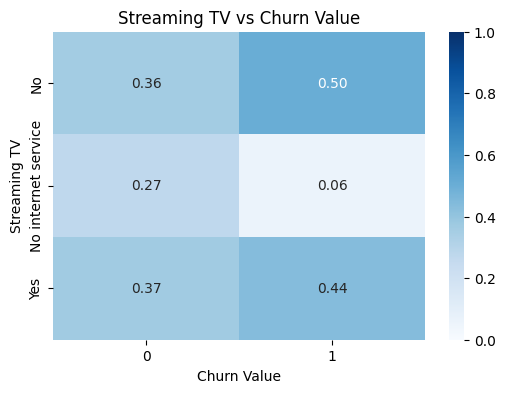

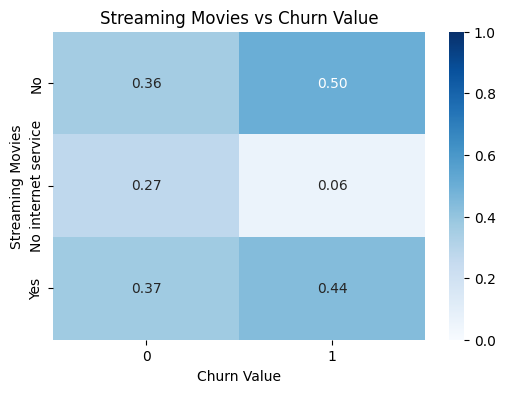

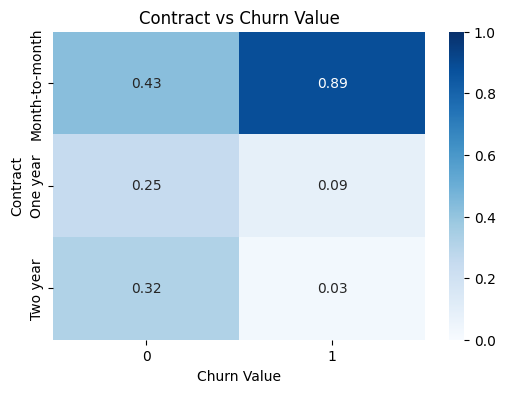

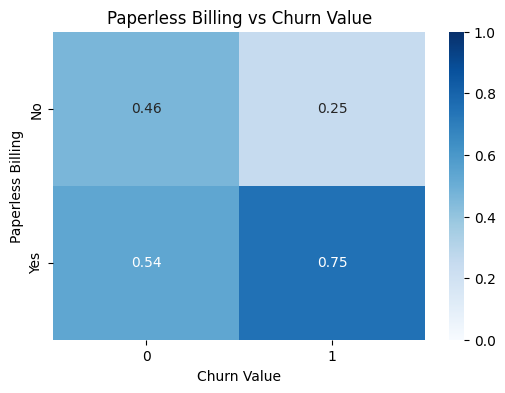

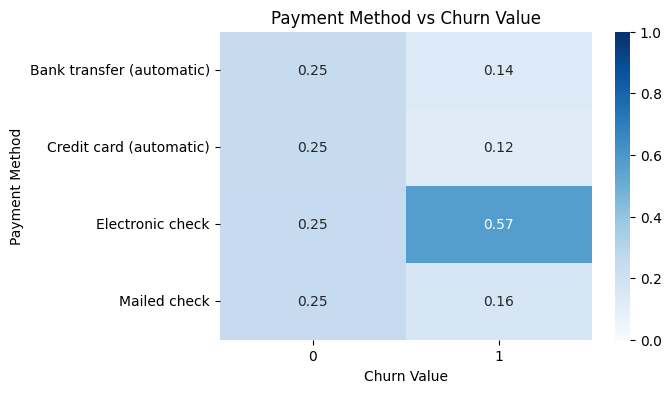

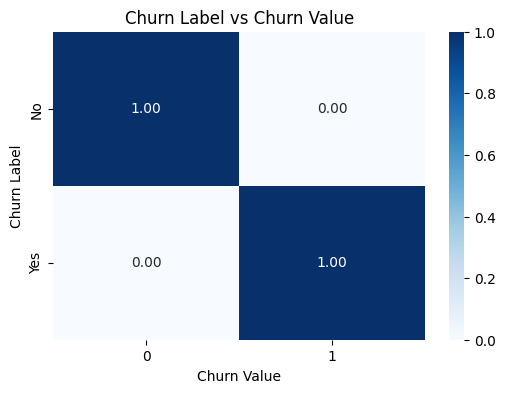

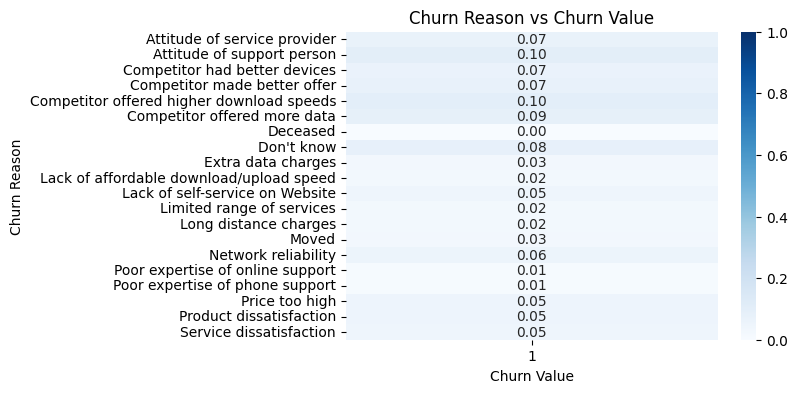

In [56]:
# Variable objetivo
target = "Churn Value"

# Variables cualitativas tipo object
categorical_cols = df.select_dtypes(include=['object']).columns


for col in categorical_cols:
    plt.figure(figsize=(6,4))
    
    tabla = pd.crosstab(df[col], df[target], normalize='columns')
    
    sns.heatmap(tabla, 
                annot=True, 
                fmt='.2f', 
                vmin=0, vmax=1,
                cmap="Blues")
    
    plt.title(f"{col} vs {target}")
    plt.ylabel(col)
    plt.xlabel(target)
    plt.show()